In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Add current dir to path to import sparse_classifier
sys.path.append(os.path.abspath("."))
from sparse_classifier import SparseClassifier
from conquer3d.data.dataset.digit3d import SparseDigit3D
from conquer3d.data.collate.sparse_tensor import sparse_collate_fn
from torchsparse import SparseTensor
import conquer3d as c3d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
print("Loading Dataset...")
test_dataset = SparseDigit3D(root="~/.conquer3d/", train=False, download=False, cached=True)

print("Loading Model...")
model = SparseClassifier(num_classes=10).to(device)
ckpt_path = "sparse_classification.pt"
if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"Loaded weights from {ckpt_path}")
else:
    print(f"Warning: {ckpt_path} not found. Using untrained weights.")
model.eval()


Loading Dataset...
Loading Model...
Loaded weights from sparse_classification.pt


SparseClassifier(
  (stem): Sequential(
    (0): Conv3d(8, 32, kernel_size=(3, 3, 3), bias=False)
    (1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): SparseResBlock(
      (main): Sequential(
        (0): Conv3d(32, 32, kernel_size=(3, 3, 3), bias=False)
        (1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(32, 32, kernel_size=(3, 3, 3), bias=False)
        (4): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
      (relu): ReLU(inplace=True)
    )
    (1): SparseResBlock(
      (main): Sequential(
        (0): Conv3d(32, 32, kernel_size=(3, 3, 3), bias=False)
        (1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(32, 32, kernel_size=(3, 3, 3), bias

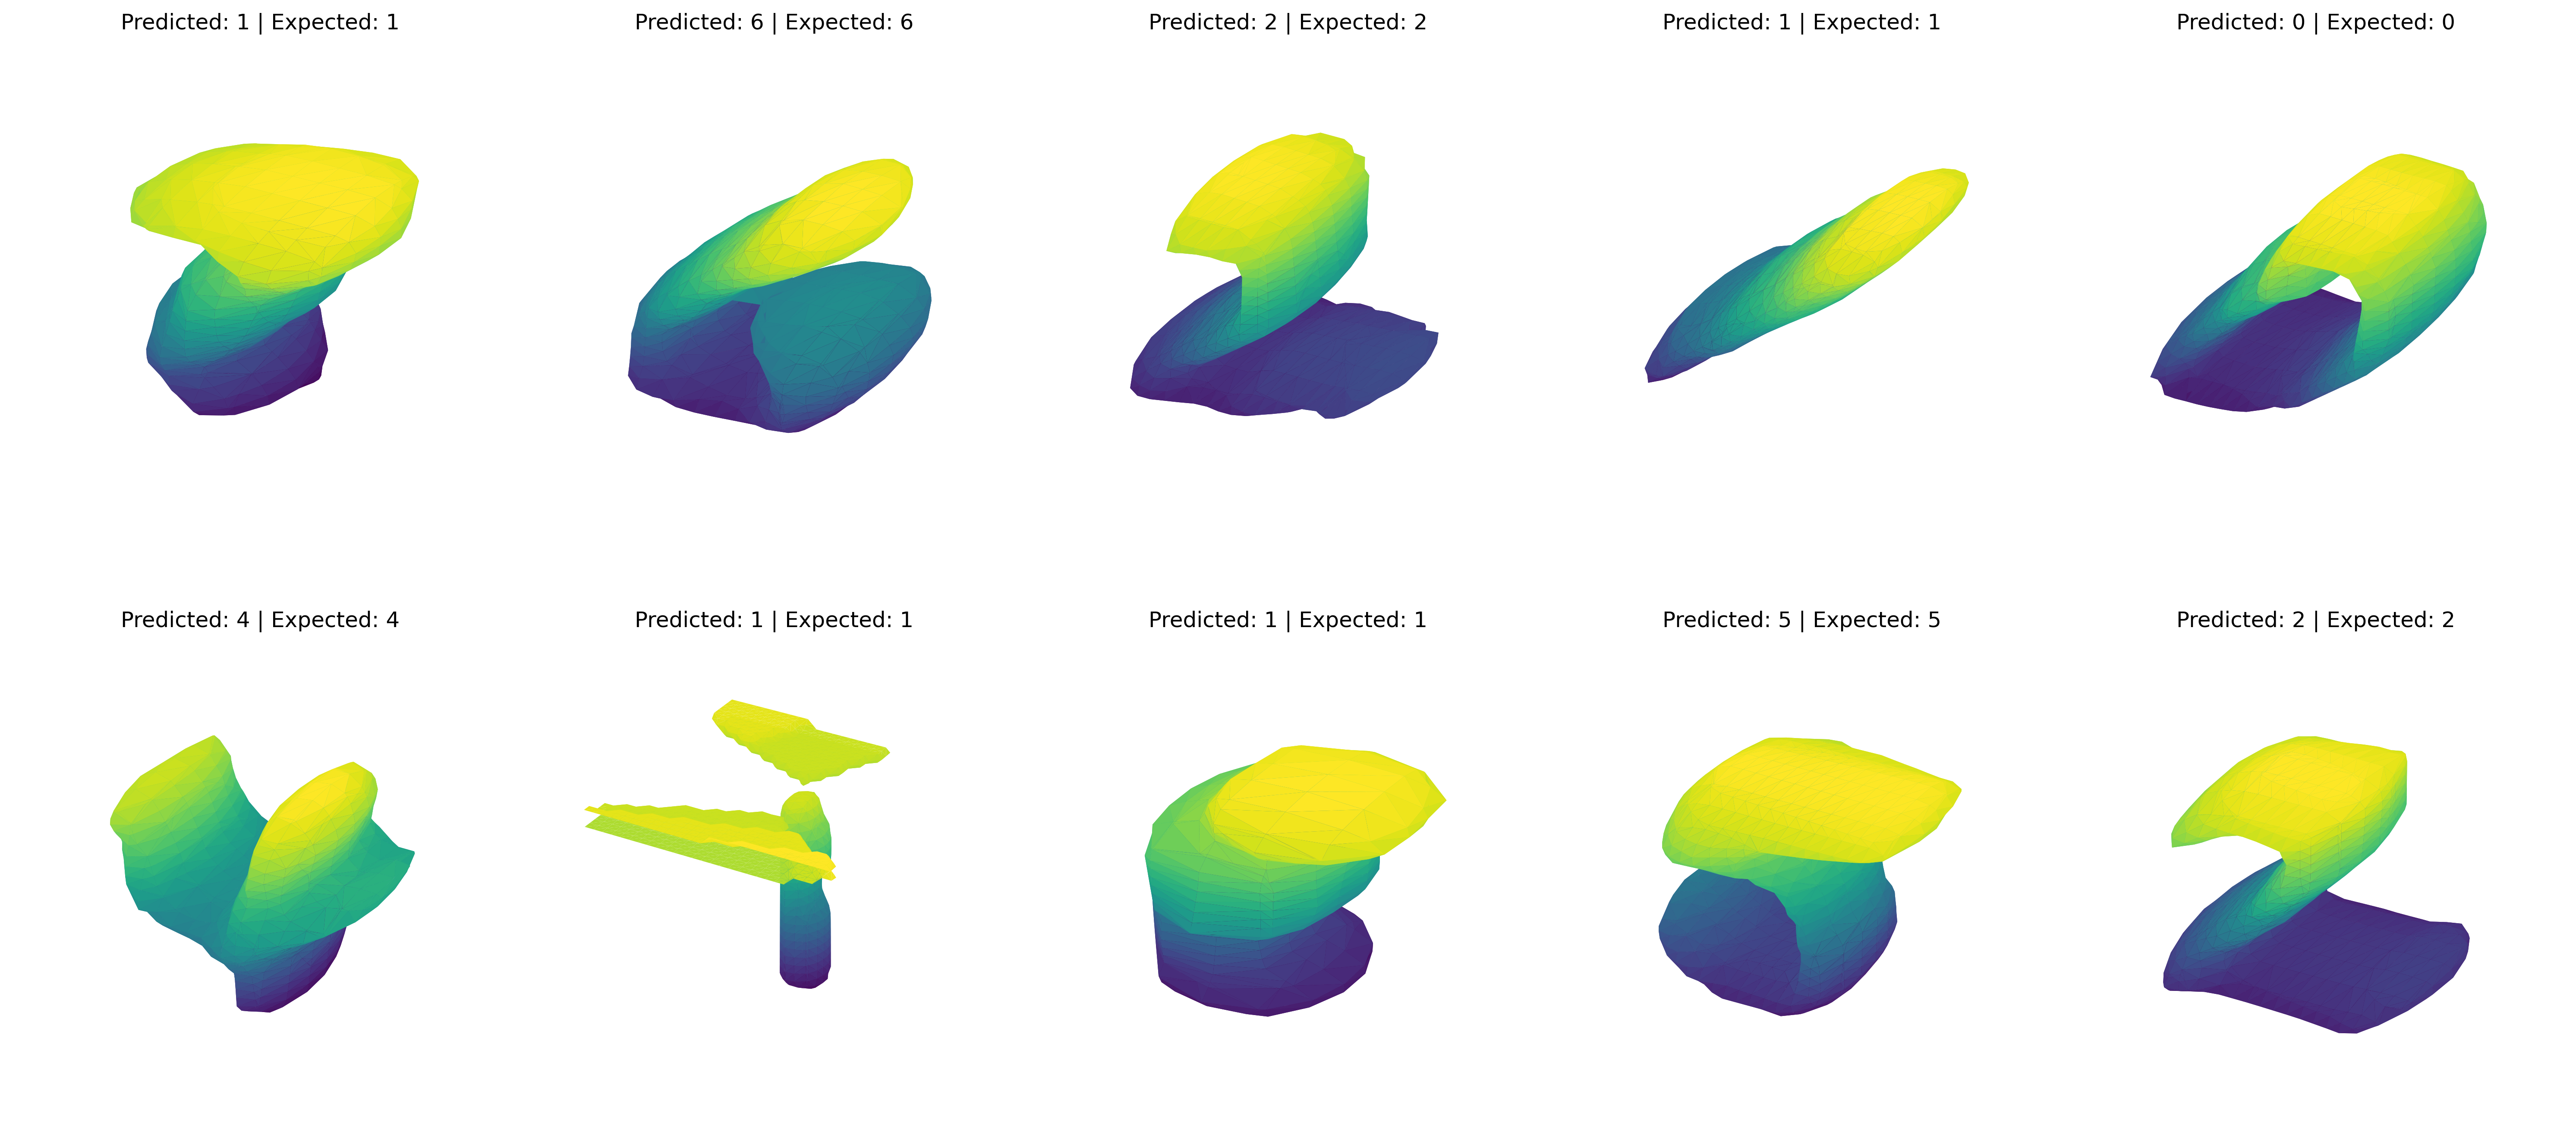

In [6]:
fig = plt.figure(figsize=(20, 10), dpi=300)

for i in range(10):
    # 1. Get sample
    coords, sdf, label = test_dataset[i]
    
    # Add batch index (0) to coords
    b_col = torch.zeros((coords.size(0), 1), dtype=coords.dtype)
    batched_coords = torch.cat([b_col, coords], dim=1).to(device)
    batched_sdf = sdf.to(device)
    
    # 2. Run Inference
    x = SparseTensor(coords=batched_coords, feats=batched_sdf)
    with torch.no_grad():
        logits = model(x)
        pred_class = torch.argmax(logits, dim=1).item()
        
    # 3. Reconstruct Mesh using Conquer3D
    unique_vertices, local_voxels, merged_sdfs = c3d.data_structure.sparse2mesh_topology(
        batched_coords, batched_sdf, grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[32, 32, 32]
    )
    vert, tri, _, _ = c3d.ops.diff_marching_cubes(unique_vertices, local_voxels, merged_sdfs, iso=0.0)
    
    vert_np = vert.detach().cpu().numpy()
    tri_np = tri.detach().cpu().numpy()
    
    # 4. Visualize
    ax = fig.add_subplot(2, 5, i + 1, projection='3d')
    ax.plot_trisurf(vert_np[:, 0], vert_np[:, 1], vert_np[:, 2], triangles=tri_np, cmap='viridis', edgecolor='none')
    
    expected_class = label.item() if isinstance(label, torch.Tensor) else label
    ax.set_title(f"Predicted: {pred_class} | Expected: {expected_class}")
    ax.axis('off')

plt.tight_layout()
plt.show()
